# `automatic_tuning` Example Notebook

This notebook provides a practical introduction to the `automatic_tuning` class and demonstrates its main features through a typical workflow.

The examples presented here are intended to help you get started quickly. They are **not** an exhaustive overview of every feature or configuration supported by the class. Instead, they focus on the core functionality and the most common usage patterns, which should cover around **99% of everyday use cases**.

For more advanced applications or specialized configurations, please refer to the class documentation.

`automatic_tuning` is a Python class that orchestrates the complete tuning procedure of a tunable microwave cavity, combining a Vector Network Analyzer (VNA) and a motorized Zaber translation stage.

`automatic_tuning` only works with a Keysight FieldFox VNA. This version is probably less up-to-date compared to the PNA version.

`automatic_tuning_PNA` is an adaptation of the base script, such that it works with Keysight PNA. This si the version used in this example notebook.

## Overview

The workflow is divided into four sequential steps:

| Step | Description |
|------|-------------|
| 1 | **Cavity mapping** — Sweep the cavity length and record VNA traces |
| 2 | **Mode fitting** — Identify and fit cavity resonance modes |
| 3 | **Starting length estimation** — Estimate the cavity length that yields the target frequency |
| 4 | **Iterative optimization** — Converge the resonance to the target frequency |

## Before starting

It is recommended to take a look to the cavity before the beginning of the optimization. You can use the theory cavity map to know where they are TE mode at your target frequency. Then you can move the motor to these lengths and measure with the VNA. You will have a first idea of your modes, and you can also try to find a good coupling of these modes, it will help. Ideally, you should be able to achieve the critical coupling, or to be very close. A $-30$ $dB$ extinction is great, with a bandwidth below $2-3$ $MHz$.

**Reminder:** Usually, the conversion between zaber_position / cavity_length is $y=113 - x$ (in $mm$).

## Initialization

The initialiaztion is based on 4 main dictionary:
- `parameters` for the global experimental parameters
- `map_metadata` for the mapping configuration (Step 1)
- `fit_metadata` for the fitting configuration (Step 2 & 3)
- `opt_metadata`for the optimization configuration (Step 4)

and one `float` value:
- `f0` the target frequency (in Hz)

### Parameters

| Key | Description |
|-----|-------------|
| `base_folder` | Root folder for data storage |
| `script_name` | Name of the calling script |
|-----|-------------|
| `zaber_port` | Serial port of the Zaber stage (Usually `"COM4"` or `"COM5"`) |
| `verb_zaber` | Verbosity flags |
| `default_velocity` | Default stage velocity (mm/s) (Recommended value: between `1` and `2`) |
| `zaber_min` | Stage travel limits (mm) (Usually `0`) |
| `zaber_max` | Stage travel limits (mm) (Usually `50`) |
| `zaber_accuracy` | Stage positioning accuracy (mm) (Usually `50e-6`) |
|-----|-------------|
| `vna_ip` | IP address of the VNA |
| `verb_vna` | Verbosity flags |
| `vna_auto_scale` | Auto-scale VNA display (`bool`) |
|-----|-------------|
| `total_cavity_length` | Total cavity length (mm) (Usually `152`) |
| `piston_thickness` | Piston thickness (mm) (Usually `20`) |
| `zaber_zero` | Zaber zero offset (mm) (Usually `19`) |
| `cavity_radius` | Cavity radius (mm) (usually `25`) |

The last parameters of this dictionary are used to convert the position of the Zaber motor to the length of the cavity. `zaber_zero` corresponds to the visible length of the cavity when the motor is at its zero position (the length between the piston and the boudary of the cavity). This length is used since it's measurable even when the cavity is fully built.

`total_cavity_length` is literaly the total length of the inside cylinder (so it is more than the maximum length of the filter length when the motor is at its zero position)

### Map Metadata

| Key | Description |
|-----|-------------|
| `dataset_name` | HDF5 dataset name |
| `loop_name` | Loop parameter name |
| `cavity_lengths` | Array of cavity lengths to sweep (mm) |
|-----|-------------|
| `trace` | VNA measurement (Usually `"S21"`) |
| `center_frequency` | VNA center frequency (Hz) (Usually `f0`) |
| `span` | VNA span (Hz) (Usually `100e6`) |
| `points` | Number of frequency points |
| `power` | VNA output power (dBm) |
| `ifbw` | IF bandwidth (Hz) |

### Fit Metadata

| Key | Description |
|-----|-------------|
| `remove_edelay` | Remove electrical delay before fitting (list). See `analysis_functions` documentation for more details. |
| `span` | Frequency span around the theoretical points to fit the data from the cavity map. |
| `threshold_length` | Used to triger a warning if the starting length of the optimization is to close to the boudaries of the linear stage. |

### Optimization Metadata

| Key | Description |
|-----|-------------|
| `dataset_name` | HDF5 dataset name |
| `loop_name` | Loop parameter name |
|-----|-------------|
| `trace` | VNA measurement (Usually `"S21"`) |
| `center_frequency` | Target frequency for the optimization **AND** center frequency of the VNA (Hz) (Usually `f0`) |
| `span` | VNA span during optimization (Hz) |
| `points` | Number of frequency points |
| `power` | VNA output power (dBm) |
| `ifbw` | IF bandwidth (Hz) |
|-----|-------------|
| `circle_fit` | Do a circle fit using `analysis_functions.core` if True. Else, perform an np.argmin to determine the resoannce frequency (bool) |
| `remove_edelay` | Remove electrical delay before fitting (list). See `analysis_functions` documentation for more details. Useless if `circle_fit` is `False` |
|-----|-------------|
| `max_movement` | Maximum allowed length correction per step (mm) (usually `1`) |
| `gain` | Optimization gain $G$ (Usually `0.9`) |
| `threshold` | Convergence criterion (Hz) (Usually `5e3`) |
| `max_iter` | Maximum number of iterations (Usually `50`) |

**Note:** The `center_frequency` has two roles: The center frequency of the VNA **AND ALSO** the target frequency of the optimization. This is useful when you want to change of few $kHz$ the desired frequency, without restarting from zero the optimization.


### Python

In [1]:
from microwave_cavity import automatic_tuning_PNA

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

f_cav = 6.844957e9
f_mech = 2.057970e6 + 75.6 - 66.20

f0 = f_cav # Desired cavity frequency

parameters = {
    # Save data
    'base_folder': "E:/measurement_data_newBF/Pacome/Example_Automatic_Tuning_9999/",
    'script_name': "/Example_Automatic_Tuning.py",

    # Zaber motor
    'zaber_port': "COM4",
    'verb_zaber': False,
    'default_velocity': 2,
    'zaber_min': 0,
    'zaber_max': 50,
    'zaber_accuracy': 50e-6,

    # VNA
    'vna_ip': "TCPIP::172.19.20.36",
    'verb_vna': False,
    'vna_auto_scale': True,

    # Conversion zaber position <--> cavity length
    'total_cavity_length': 152,
    'piston_thickness': 20,
    'cavity_radius': 25,
    'zaber_zero': 19,
   }

map_metadata = {
    'dataset_name': "Cavity_map",
    'loop_name': "Cavity length (mm)",
    'cavity_lengths': np.linspace(63, 113, 501),

    'trace': "S21",
    'center_frequency': f0,
    'span': 100e+06,
    'points': 10001,
    'power': 0,
    'ifbw': 100e+03
    }

fit_metadata = {
    'remove_edelay': [0, 50, 0, 0],
    'span': 50e+06,
    'threshold_length': 1
}

opt_metadata = {
    'dataset_name': "Optimization",
    'loop_name': "Cavity length (mm)",

    'trace': "S21",
    'center_frequency': f0,
    'span': 50e+06,
    'points': 10001,
    'power': 0,
    'ifbw': 10e+03,

    'circle_fit': False,
    'remove_edelay': [0, 100, 0, 0],
    'max_movement': 1,
    'gain': 0.9,
    'max_iter': 50,
    'threshold': 50e+03
}

auto = automatic_tuning_PNA(
    f0 = f0,
    map_metadata = map_metadata,
    fit_metadata = fit_metadata,
    opt_metadata = opt_metadata,
    parameters = parameters)

Loading BokehJS ...

c:\Users\TUD213952\AppData\Local\anaconda3\envs\cavity_filter\lib\site-packages\pyvisa\highlevel.py:2823: FutureWarning: @ni backend name is deprecated and will be removed in 1.12. Use @ivi instead. Check the documentation for details
  warnings.warn(


Global NI ResourceManager created
Agilent Technologies,N5222A,MY56022568,A.10.60.03



[Zaber] READY!


## Map of the cavity 

First thing to do is to make a map of the available TEM modes in the cavity around your target frequency (given by `span` of `map_metadata`). A span of 100 $MHz$ is a good value.

To do this map, the zaber motor will move (defined by `cavity_lengths`) and the VNA will do a measurement for each length.

If you already have a cavity map stored in your files, you can skip this step and move to the second one.

If needed, you can also re-define `map_metadata`: It will overwrite the old `map_metadata`. If `map_metadata` is `None`, it keeps the one defined during the initialization.

In [32]:
auto.cavity_map(map_metadata = None)

Cavity mapping...
Center frequency: 6.844957000 GHz
VNA span: 100.000000 MHz
[]
Data will be saved to folder:
E:\measurement_data_newBF\Pacome\Example_Automatic_Tuning_9999\2026-07-13_17.14.29_0001_Example_Automatic_Tuning


  0%|          | 0/501 [00:00<?, ?it/s]

Cavity length: 63.000000 mm


  0%|          | 1/501 [00:14<1:58:59, 14.28s/it]

Cavity length: 63.100000 mm


...

Cavity length: 112.900000 mm


100%|█████████▉| 500/501 [06:01<00:00,  1.49it/s]

Cavity length: 113.000000 mm


100%|██████████| 501/501 [06:02<00:00,  1.38it/s]

Cavity mapping done.


## Fit of the cavity map

Once you have a cavity map, you want to fit the branches of each mode in order to determine the quality of these modes for filtering. This part relies on `cavity_analysis` functions. More details are provided in the example jupyter notebook.

First, we plot the cavity map
- If you want to use the map previously done: `map_path = None`
- If you want to use an other map from your own files: `map_path = path\to\your\map_folder` (same path as the usual path you provided for every function in the SteeleLab)

To easily identify the modes, you must overlay the theory with `plot_theory = True`.

If needed, you can also re-define `fit_metadata`: It will overwrite the old `fit_metadata`. If `fit_metadata` is `None`, it keeps the one defined during the initialization.


Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -41.256302221290 * (2*pi*freq) + 1759.335350123120


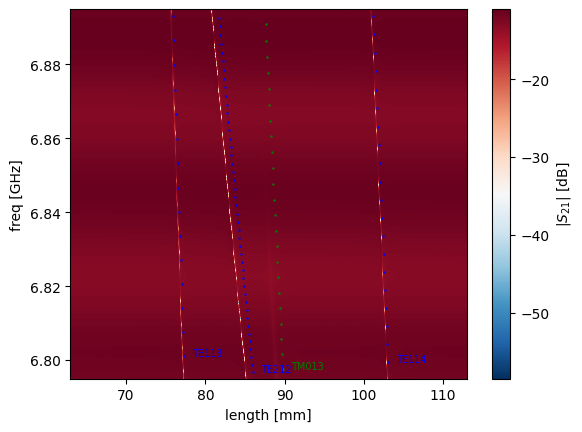

In [2]:
fig, ax = plt.subplots()
auto.plot_cavity_map(map_path = 'E:/measurement_data_newBF/Pacome/Example_Automatic_Tuning_9999/2026-07-13_17.14.29_0001_Example_Automatic_Tuning',
                     plot_theory = True,
                     fit_metadata = None,
                     ax = ax,
                     marker='.', s=2)
plt.show()

Then, this function fits each branche. If `mode_ids` is `None`, it will fit all TE modes of the cavity map. Otherwise, you can select which modes you want to fit. Usually TE113, TE114, TE115 are good modes with small $\kappa_t$ (but it's not necessarily true. It also depends if you were good to find the shape and position for the pin before the beginiing of this automatization...)

`plot_mask` is to plot the data fitted during the process (we don't plot all the map, it's full of nothing). It can be useful if you have weird results from the fits, to check if everything is ok.

`plot_results` is very useful since it allows you to select the modes with good bandwidth.

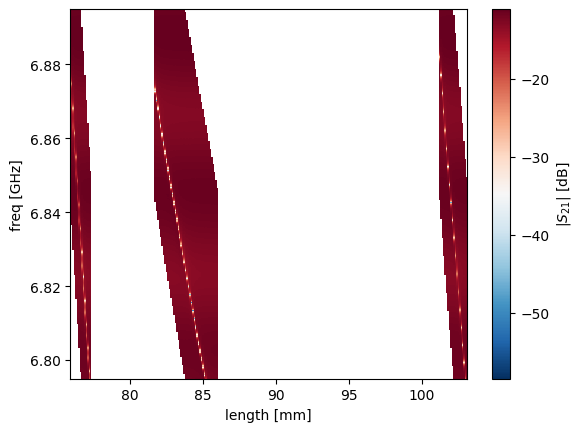

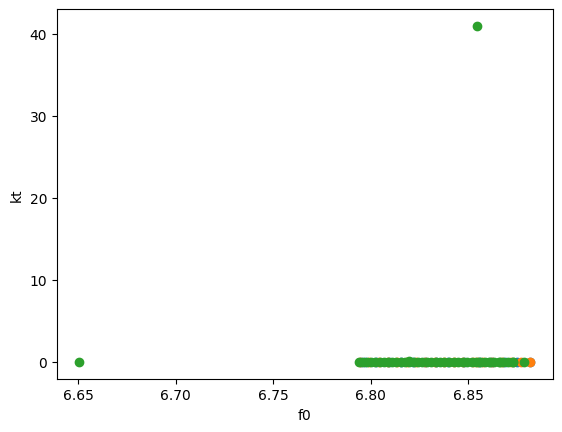

In [3]:
auto.fit_map(mode_ids = None,
             plot_mask = True,
             plot_results = True)

If you want more plots, you can plot any configuration of `length`, `f0`, and `kt`.

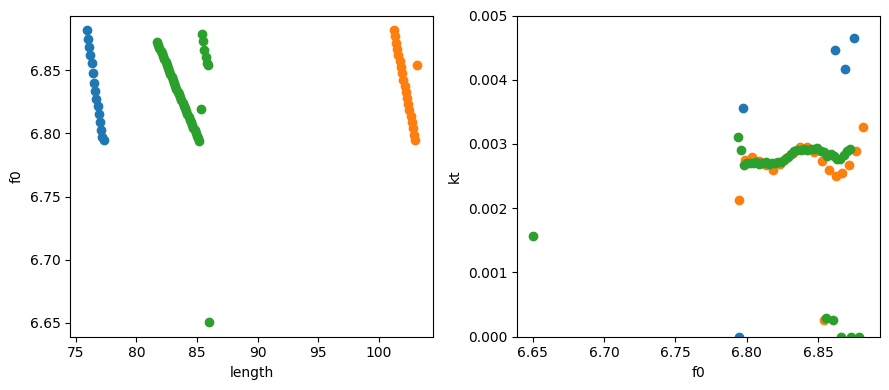

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
auto.analysis.plot_data_results(x='length', y='f0', ax=ax[0])
auto.analysis.plot_data_results(x='f0', y='kt', ax=ax[1])
ax[1].set_ylim(0, 5e-3)
fig.tight_layout()
plt.show()

*Note: I forgot to add `ax.legend()` for every plot, I'm sorry. Indeed, all plots and dictionaries are created such that all modes are easily identifiable with their label $TE(M)nlm$. This is very useful to know wich mode is which mode...*

Now, we see that two modes seem very good, so we fit only them to be sure.

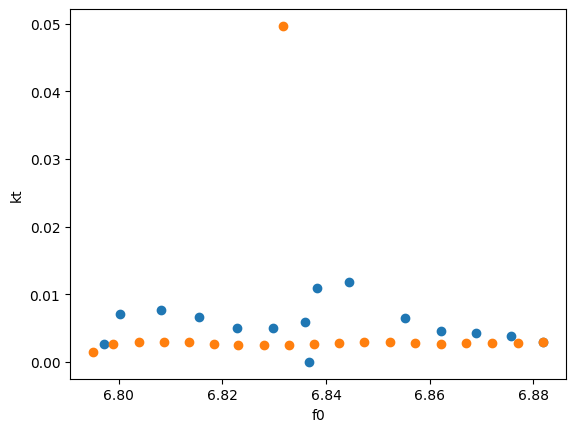

In [5]:
auto.fit_map(mode_ids = ['TE113', 'TE114'],
             plot_mask = False,
             plot_results = True)

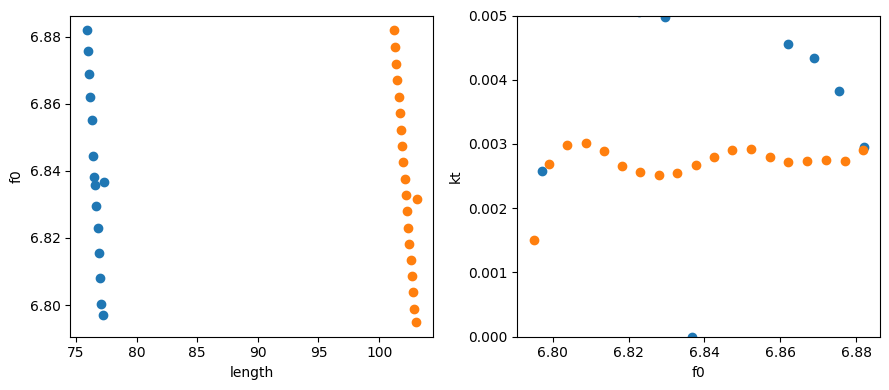

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
auto.analysis.plot_data_results(x='length', y='f0', ax=ax[0])
auto.analysis.plot_data_results(x='f0', y='kt', ax=ax[1])
ax[1].set_ylim(0, 5e-3)
fig.tight_layout()
plt.show()

**Looking at the results, we will continue TE114 since the coupling rate is stable a small enough.**

## Starting points

We're almost ready to start. We now have two modes, and you have to determine the starting position for the motor. This is the goal of this function. If you need, it prints the results. 

This functions does one thing in the background we don't see: It makes a linear fit of the mode. Then, the slope is very useful for the optimization just after: Given an frequency error, it converts this frequency error, to a delta position for the motor such that we approach the target frequency.

One of the printed parameter is the resolution. It's the frequency delta given `zaber_accuracy`. If you put `50e-6` (50nm is the minimal step for this motor), we optain a value of few $kHz$. Theoreticaly, smaller the value is, better the optimization should be...

Also, if the starting point is to close to the limit of the motor, you're supposed to have a warning (depending on the value of `threshold_length`).

In [7]:
auto.starting_length(mode_ids = ['TE114'],
                     print_results = True)

Mode: TE114 | Starting length: 101.975727 mm | Frequency resolution: 2.125 kHz


## Optimization

Now it's time for your last choice: You must choose one mode. The motor will move to this mode and start its optimization.

Do determine the resonance frequency after each measurement before calculating the frequency error, you have two possibilities:
- Using a complex circle fit using `steele-lab-analysis-functions`: `circle_fit = True`
- Or determine the resonance frequency by taking the minimum of the magnitude of $|S21|$: `circle_fit = False`

The first method should perfectly work. However, it seems that the convergence is not perfect and you can have around $100$ $kHz$ between the filter frequency and your target frequency. As for the second method, you must be careful of the value of the `threshold` you choose. This value cannot be smaller than the resolution of the VNA (given by the `span` and the number of `points`).

As you can see, it's recommended to choose a `gain` $G<1$. It means that for each iteration, the correction isn't `delta_length` but `gain * delta_length`. It's to avoid going too far, and suffer the backlash of the motor. One drawback: the optimization is a bit slower.

It's a good idea to do this optimization in several steps:
- An optimization with a large `threshold` since the starting lenth is sometime far from the reality
- An optimization with a small `threshold` to finally hits the target frequency

After this second optimization, you may want to move (carefully) the pin to have a better coupling. Therefore, this operation can change the frequency of the filter. Therefore, you have to redo an optimization. You can do as many optimization as you want.

If needed, you can also re-define `opt_metadata`: It will overwrite the old `opt_metadata`. If `opt_metadata` is `None`, it keeps the one defined during the initialization, or the last one defined. It's very usefull if you do several optimization with different `threshold`.

### First optimization

For the first optimization, you must define `reset = True`. it will initialize all the arrays and dicts used during the optimization

In [8]:
auto.optimization(mode_id = 'TE114',
                  reset = True,
                  opt_metadata = None)

Go to TE114: length = 101.975727 mm

#################
Iteration 1 | Length: 101.975727 mm
['2026-07-13_17.14.29_0001_Example_Automatic_Tuning']
Data will be saved to folder:
E:\measurement_data_newBF\Pacome\Example_Automatic_Tuning_9999\2026-07-13_17.33.01_0002_Example_Automatic_Tuning
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -45.921299308697 * (2*pi*freq) + 1965.478637069813
Frequency: 6.843547000 GHz
Frequency error: 1410.000 kHz | 0.020599 %
Delta length: -29.865 um

#################
Iteration 2 | Length: 101.945862 mm
['2026-07-13_17.14.29_0001_Example_Automatic_Tuning', '2026-07-13_17.33.01_0002_Example_Automatic_Tuning']
Data will be saved to folder:
E:\measurement_data_newBF\Pacome\Example_Automatic_Tuning_9999\2026-07-13_17.33.03_0003_Example_Automatic_Tuning
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -45.858902596297 * (2*pi*freq) + 1962.809484320174
Freque

### Next optimizations

For the next optimizations, you must define `rest = False` to continue to save your data in the arrays and dicts after the previous data from the last optimizations. You can also redefine `opt_metadata` (especially the `threshold` and the target frequency `center_frequency`)

In [9]:
opt_metadata = {
    'dataset_name': "Optimization",
    'loop_name': "Cavity length (mm)",

    'trace': "S21",
    'center_frequency': f0,
    'span': 10e+06,
    'points': 10001,
    'power': 0,
    'ifbw': 10e+03,

    'circle_fit': False,
    'remove_edelay': [0, 100, 0, 0],
    'max_movement': 1,
    'gain': 0.9,
    'max_iter': 50,
    'threshold': 5e+03
}

auto.optimization(mode_id = 'TE114',
                  reset = False,
                  opt_metadata = opt_metadata)

Return to the last optimized length: 101.943638 mm

#################
Iteration 1 | Length: 101.943638 mm
['2026-07-13_17.14.29_0001_Example_Automatic_Tuning', '2026-07-13_17.33.01_0002_Example_Automatic_Tuning', '2026-07-13_17.33.03_0003_Example_Automatic_Tuning', '2026-07-13_17.33.06_0004_Example_Automatic_Tuning']
Data will be saved to folder:
E:\measurement_data_newBF\Pacome\Example_Automatic_Tuning_9999\2026-07-13_17.33.53_0005_Example_Automatic_Tuning
Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -47.918178659893 * (2*pi*freq) + 2057.748396732586
Frequency: 6.844978000 GHz
Frequency error: -21.000 kHz | 0.000307 %
Delta length: 0.445 um

#################
Iteration 2 | Length: 101.944082 mm
['2026-07-13_17.14.29_0001_Example_Automatic_Tuning', '2026-07-13_17.33.01_0002_Example_Automatic_Tuning', '2026-07-13_17.33.03_0003_Example_Automatic_Tuning', '2026-07-13_17.33.06_0004_Example_Automatic_Tuning', '2026-07-13_17.33.53_0005

## Results of the automatic tuning

It's useful to check how the tuning went, and if the results is ok. Thus, you should plot the last VNA trace, and compare this trace to te target frequency. For this example, we took the example of sideband cooling, with a pump on the RSB, and the filter centered on the cavity frequency.

The second plot is the evolution of the different parameters during the optimization.

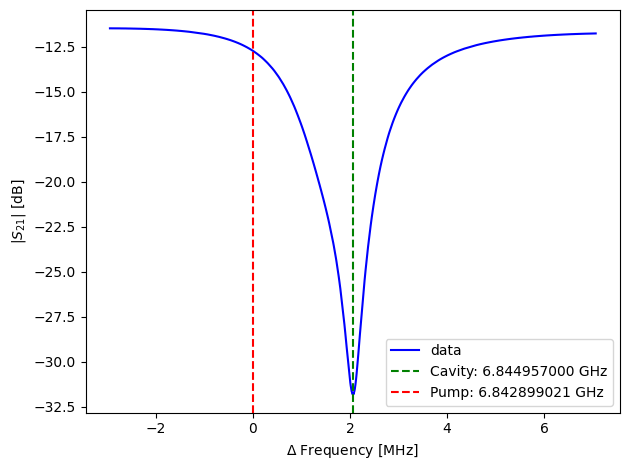

In [11]:
trace = auto.list_data_opt[-1]

data_xr = trace.isel(length=0)

fig, ax = plt.subplots()

ax.plot((data_xr.freq.values - ((auto.f0 - f_mech) * 1e-09))*1e+03, data_xr.mag.values, color = 'blue', label='data')
ax.axvline(f_mech * 1e-06, color='green', linestyle='--', label=f'Cavity: {auto.f0*1e-09:.9f} GHz')
ax.axvline(0, color='red', linestyle='--', label=f'Pump: {(auto.f0 - f_mech)*1e-09:.9f} GHz')
ax.set_xlabel('$\Delta$ Frequency [MHz]')
ax.set_ylabel('$|S_{21}|$ [dB]')
ax.legend()

fig.tight_layout()
plt.show()

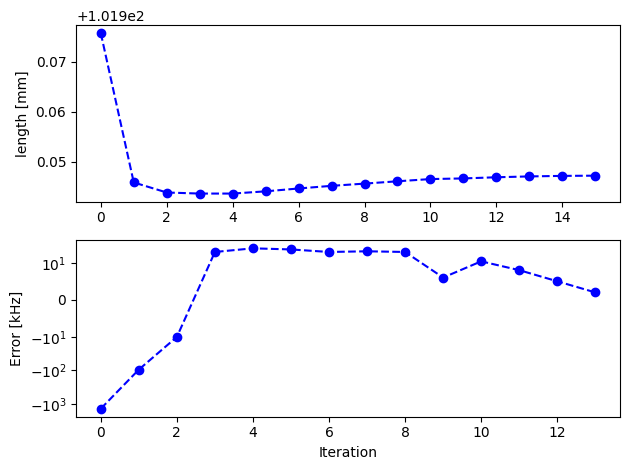

In [14]:
convergence = auto.dict_main_params

fig, ax = plt.subplots(2, 1)

ax[0].plot(convergence['length'], 'bo--')
ax[0].set_ylabel('length [mm]')


ax[1].plot((np.array(convergence['freq']) - f0)*1e-3, 'bo--')
ax[1].set_yscale('symlog', linthresh=10)
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Error [kHz]')

fig.tight_layout()
plt.show()

## Close devices

It's important to close the connections when you're fully done. 

In [15]:
auto.close_devices()

[Zaber] Connection closed.


However, if you have to re-open the connections without restarting everything, you can use these two functions :

In [ ]:
auto.init_vna()
auto.init_zaber()